# 06 - Comparison Across Methods

Aggregates the metric JSONs from `03_baseline_tabddpm`, `04_adjusted_tabddpm`,
`05_naive_scaling` (across all available seeds) and produces:

1. **Overall metrics table** - mean ± std across seeds, per method.
2. **Per-cardinality JSD breakdown** - low (K≤5) / med (5<K≤16) / high (K>16) bins.
3. **Per-feature comparison** - all 8 categorical features, all methods, side-by-side.
4. **Correlation L2 + TSTR comparison** - cross-feature dependencies and utility metric.
5. **Explicit verdict** on the three hypothesis criteria from the project specification.
6. **Report-ready figures** saved to `outputs/figures/`.

This notebook can be executed at any time - it loads whatever metric JSONs are in
`outputs/metrics/`. With only some configs completed, it gives a partial comparison.


## Setup

In [11]:
import os, sys
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
sys.path.insert(0, str(Path.cwd()))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.data_utils import load_meta, CAT_COLS

plt.rcParams['figure.dpi']  = 110
plt.rcParams['axes.grid']   = True
plt.rcParams['grid.alpha']  = 0.3
plt.rcParams['savefig.dpi'] = 150


## 1. Load Results

In [12]:
METRICS_DIR = Path("outputs/metrics")
results = []
for f in sorted(METRICS_DIR.glob("*.json")):
    results.append(json.loads(f.read_text()))

if not results:
    raise RuntimeError(
          f"No JSONs found in {METRICS_DIR}. Execute 03/04/05 first.")

df = pd.DataFrame(results)
print(f"Loaded {len(df)} results")
print(f"  methods : {sorted(df['method'].unique().tolist())}")
print(f"  seeds   : {sorted(df['seed'].unique().tolist())}")
print()
df[["method", "seed", "jsd_mean", "correlation_l2", "xgb_acc", "xgb_f1"]].round(4)


Loaded 9 results
  methods : ['adjusted', 'baseline', 'naive']
  seeds   : [1, 7, 42]



,method,seed,jsd_mean,correlation_l2,xgb_acc,xgb_f1
0,adjusted,1,0.0139,0.4191,0.8348,0.6461
1,adjusted,42,0.0155,0.4218,0.8320,0.6661
2,adjusted,7,0.0149,0.4229,0.8457,0.6673
3,baseline,1,0.0378,0.5519,0.8408,0.6375
4,baseline,42,0.0374,0.5679,0.8371,0.6586
5,baseline,7,0.0381,0.5472,0.8481,0.6601
6,naive,1,0.0945,0.7011,0.8284,0.6689
7,naive,42,0.0927,0.6935,0.8178,0.6683
8,naive,7,0.0917,0.6704,0.8240,0.6536


## 2. Overall Metrics Table

In [13]:
# Mean ± std across seeds, per method
def fmt(m, s): return f"{m:.4f} ± {s:.4f}"

rows = []
for method in df['method'].unique():
    sub = df[df['method'] == method]
    rows.append({
        "method":          method,
        "n_seeds":         len(sub),
        "JSD mean":        fmt(sub['jsd_mean'].mean(),       sub['jsd_mean'].std()),
        "correlation_L2":  fmt(sub['correlation_l2'].mean(), sub['correlation_l2'].std()),
        "XGB acc":         fmt(sub['xgb_acc'].mean(),        sub['xgb_acc'].std()),
        "XGB F1":          fmt(sub['xgb_f1'].mean(),         sub['xgb_f1'].std()),
        "LR acc":          fmt(sub['lr_acc'].mean(),         sub['lr_acc'].std()),
        "LR F1":           fmt(sub['lr_f1'].mean(),          sub['lr_f1'].std()),
    })
overall = pd.DataFrame(rows).set_index('method')
print("Overall metrics (mean ± std across seeds):")
overall


Overall metrics (mean ± std across seeds):


,n_seeds,JSD mean,correlation_L2,XGB acc,XGB F1,LR acc,LR F1
method,,,,,,,
adjusted,3,0.0147 ± 0.0008,0.4212 ± 0.0020,0.8375 ± 0.0072,0.6598 ± 0.0119,0.8339 ± 0.0022,0.6549 ± 0.0076
baseline,3,0.0378 ± 0.0003,0.5557 ± 0.0108,0.8420 ± 0.0056,0.6521 ± 0.0127,0.8334 ± 0.0008,0.6474 ± 0.0035
naive,3,0.0930 ± 0.0014,0.6883 ± 0.0160,0.8234 ± 0.0053,0.6636 ± 0.0087,0.8197 ± 0.0069,0.6496 ± 0.0068


## 3. Per-Cardinality JSD Breakdown

Categorical features grouped into low / medium / high cardinality bins.

Per-column Jensen-Shannon divergence (in bits):

$$\text{JSD}(P \| Q) = \frac{1}{2}D_{\text{KL}}(P \| M) + \frac{1}{2}D_{\text{KL}}(Q \| M), \quad M = \tfrac{1}{2}(P + Q)$$

If MI-adjustment helps, the improvement is expected to be most visible in the **high** bin - that's the core hypothesis.


In [14]:
meta = load_meta()
cardinalities = meta["cardinalities"]

bands = {
    "low (K≤5)":    [i for i, K in enumerate(cardinalities) if K <= 5],
    "med (5<K≤16)": [i for i, K in enumerate(cardinalities) if 5 < K <= 16],
    "high (K>16)":  [i for i, K in enumerate(cardinalities) if K > 16],
}
print("Cardinality bins:")
for label, idx in bands.items():
    cols_in_bin = [CAT_COLS[i] for i in idx]
    print(f"  {label:<15s}: {cols_in_bin}")


Cardinality bins:
  low (K≤5)      : ['race', 'sex']
  med (5<K≤16)   : ['workclass', 'education', 'marital-status', 'occupation', 'relationship']
  high (K>16)    : ['native-country']


In [15]:
rows = []
for method in df['method'].unique():
    sub = df[df['method'] == method]
    jsd_arr = np.array([np.array(r) for r in sub['jsd_per_col']])
    row = {"method": method, "n_seeds": len(sub)}
    for label, idx in bands.items():
        if not idx:
            row[label] = "-"; continue
        sm = jsd_arr[:, idx].mean(axis=1)
        row[label] = f"{sm.mean():.4f} ± {sm.std():.4f}"
    rows.append(row)
per_card = pd.DataFrame(rows).set_index('method')
print("Per-cardinality JSD (bits - lower is better):")
per_card


Per-cardinality JSD (bits - lower is better):


,n_seeds,low (K≤5),med (5<K≤16),high (K>16)
method,,,,
adjusted,3,0.0170 ± 0.0003,0.0132 ± 0.0007,0.0178 ± 0.0018
baseline,3,0.0280 ± 0.0007,0.0239 ± 0.0002,0.1267 ± 0.0019
naive,3,0.0321 ± 0.0013,0.0399 ± 0.0008,0.4800 ± 0.0047


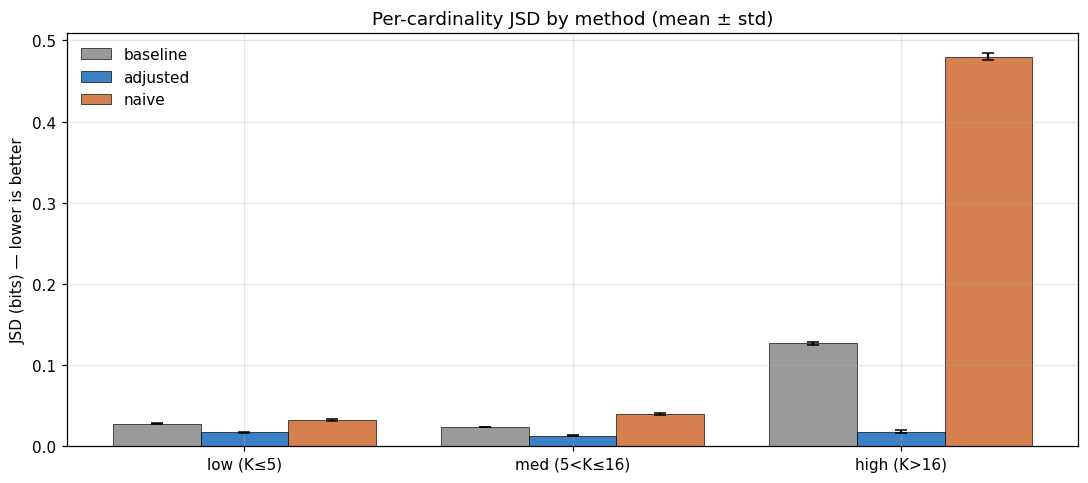

In [16]:
_known_order = ['baseline', 'adjusted', 'adjusted_p25', 'adjusted_p50', 'adjusted_p75', 'adjusted_kmed', 'naive']
methods_order = [m for m in _known_order if m in df['method'].unique()]
methods_order += [m for m in df['method'].unique() if m not in methods_order]

_base_colors = {
    'baseline': '#888888', 'adjusted': '#1a6bbf', 'naive': '#cf6a30',
    'adjusted_p25': '#74b9e8', 'adjusted_p50': '#3d8fd9', 'adjusted_p75': '#2367a0',
    'adjusted_kmed': '#2e8b57',
}
colors_map = {m: _base_colors.get(m, f'C{i}') for i, m in enumerate(methods_order)}

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(bands))
n_methods = len(methods_order)
width = 0.8 / max(n_methods, 1)
for i, method in enumerate(methods_order):
    sub = df[df['method'] == method]
    jsd_arr = np.array([np.array(r) for r in sub['jsd_per_col']])
    means = []; stds = []
    for label, idx in bands.items():
        if not idx:
            means.append(0); stds.append(0); continue
        sm = jsd_arr[:, idx].mean(axis=1)
        means.append(sm.mean()); stds.append(sm.std())
    offset = (i - (n_methods-1)/2) * width
    ax.bar(x + offset, means, width, yerr=stds, label=method,
            color=colors_map[method], capsize=4, alpha=0.85,
            edgecolor='black', linewidth=0.5)
ax.set_xticks(x); ax.set_xticklabels(list(bands.keys()))
ax.set_ylabel("JSD (bits) - lower is better")
ax.set_title("Per-cardinality JSD by method (mean ± std)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("outputs/figures/fig_jsd_by_cardinality.png", bbox_inches='tight')
plt.show()

## 4. Per-Feature Comparison

All 8 categorical features side-by-side. Helps identify whether one particular feature is driving the aggregate result.

In [17]:
# Per-feature table
rows = []
for i, (col, K) in enumerate(zip(CAT_COLS, cardinalities)):
    row = {"feature": col, "K": K}
    for method in methods_order:
        sub = df[df['method'] == method]
        jsd_arr = np.array([np.array(r) for r in sub['jsd_per_col']])
        row[method] = f"{jsd_arr[:, i].mean():.4f} ± {jsd_arr[:, i].std():.4f}"
    rows.append(row)
per_feat = pd.DataFrame(rows).set_index('feature')
print("Per-feature JSD (bits - lower is better):")
per_feat


Per-feature JSD (bits - lower is better):


,K,baseline,adjusted,naive
feature,,,,
workclass,7,0.0479 ± 0.0008,0.0303 ± 0.0016,0.0413 ± 0.0021
education,16,0.0140 ± 0.0016,0.0008 ± 0.0002,0.0755 ± 0.0027
marital-status,7,0.0271 ± 0.0012,0.0152 ± 0.0018,0.0298 ± 0.0011
occupation,14,0.0136 ± 0.0006,0.0057 ± 0.0004,0.0319 ± 0.0008
relationship,6,0.0168 ± 0.0003,0.0141 ± 0.0014,0.0212 ± 0.0023
race,5,0.0544 ± 0.0012,0.0300 ± 0.0005,0.0631 ± 0.0024
sex,2,0.0016 ± 0.0003,0.0040 ± 0.0003,0.0011 ± 0.0002
native-country,41,0.1267 ± 0.0019,0.0178 ± 0.0018,0.4800 ± 0.0047


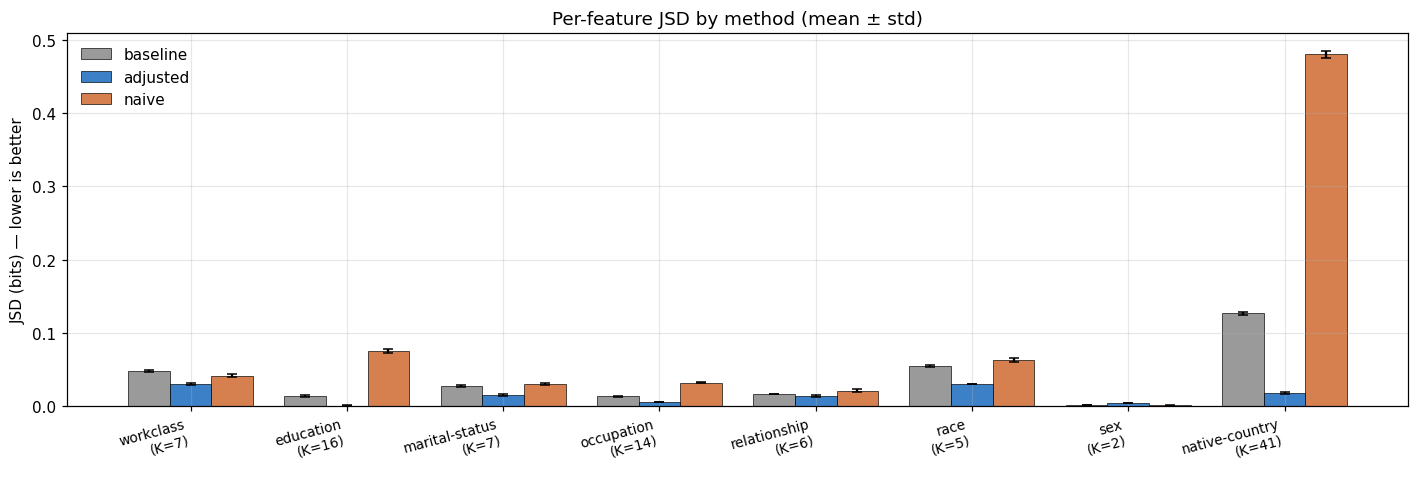

In [18]:
fig, ax = plt.subplots(figsize=(13, 4.5))
x = np.arange(len(cardinalities))
n_methods = len(methods_order)
width = 0.8 / max(n_methods, 1)
for i, method in enumerate(methods_order):
    sub = df[df['method'] == method]
    jsd_arr = np.array([np.array(r) for r in sub['jsd_per_col']])
    means = jsd_arr.mean(axis=0)
    stds  = jsd_arr.std(axis=0)
    offset = (i - (n_methods-1)/2) * width
    ax.bar(x + offset, means, width, yerr=stds, label=method,
            color=colors_map[method], capsize=3, alpha=0.85,
            edgecolor='black', linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f"{c}\n(K={K})" for c, K in zip(CAT_COLS, cardinalities)],
                   rotation=15, ha='right', fontsize=9)
ax.set_ylabel("JSD (bits) - lower is better")
ax.set_title("Per-feature JSD by method (mean ± std)")
ax.legend(frameon=False)
plt.tight_layout()
plt.savefig("outputs/figures/fig_jsd_per_feature.png", bbox_inches='tight')
plt.show()

## 5. Utility Metrics - Correlation L2 + TSTR

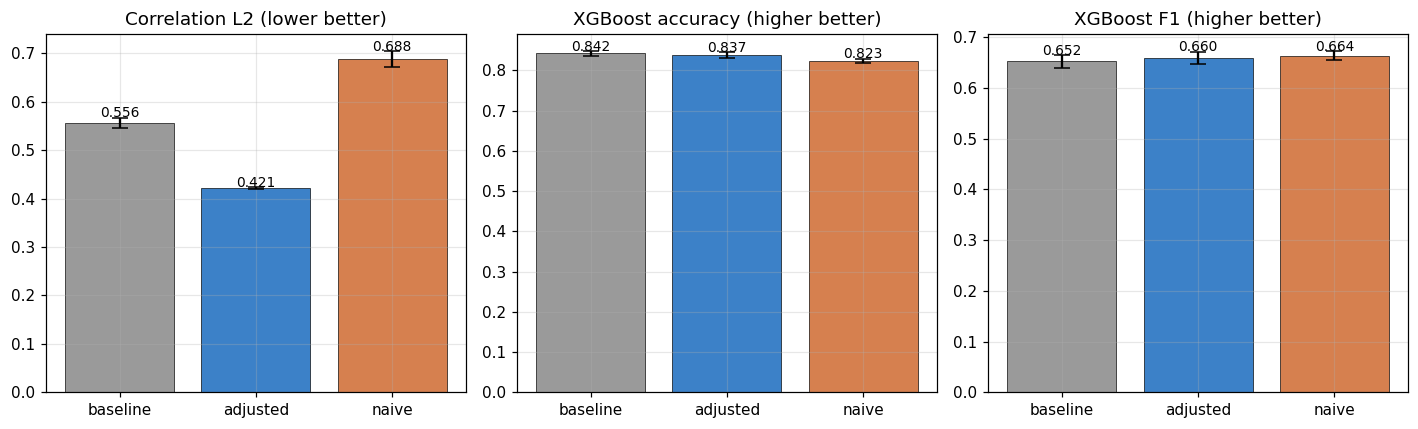

In [19]:
# Correlation L2 + TSTR plot
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
metric_keys = [("correlation_l2", "Correlation L2 (lower better)"),
                ("xgb_acc",        "XGBoost accuracy (higher better)"),
                ("xgb_f1",         "XGBoost F1 (higher better)")]

for ax, (key, title) in zip(axes, metric_keys):
    means = [df[df['method']==m][key].mean() for m in methods_order]
    stds  = [df[df['method']==m][key].std()  for m in methods_order]
    bars  = ax.bar(methods_order, means, yerr=stds,
                    color=[colors_map[m] for m in methods_order],
                    capsize=5, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_title(title); ax.set_ylabel("")
    for bar, m, s in zip(bars, means, stds):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + s + 0.001,
                 f"{m:.3f}", ha='center', fontsize=9)
plt.tight_layout()
plt.savefig("outputs/figures/fig_utility_metrics.png", bbox_inches='tight')
plt.show()


## 6. Hypothesis Verdict

Three pass/fail criteria from the project specification:

1. **Adjusted strictly beats baseline on high-K** features.
2. **Improvement exceeds inter-seed noise floor** - not just lucky seeding.
3. **Naive scaling does not match the improvement** - the MI derivation is necessary, not redundant.


In [20]:
print("=" * 72)
print("  HYPOTHESIS VERDICT")
print("=" * 72)

high_idx = [i for i, K in enumerate(cardinalities) if K > 16]
adj_methods = [m for m in methods_order if m.startswith('adjusted')]

if 'baseline' not in df['method'].unique() or not adj_methods:
    print("  Need 'baseline' and at least one 'adjusted' variant to render a verdict.")
else:
    if not high_idx:
        print("  No high-K (K>16) features in this dataset.")
    else:
        def high_K_jsd(method):
            sub = df[df['method'] == method]
            arr = np.array([np.array(r) for r in sub['jsd_per_col']])
            return arr[:, high_idx].mean(axis=1)

        b = high_K_jsd("baseline")
        print(f"\n  high-K JSD across seeds:")
        print(f"    {'method':<20s} {'mean':>8s} {'± std':>8s}  {'Δ vs baseline':>14s}")
        print(f"    {'baseline':<20s} {b.mean():>8.4f} {b.std():>8.4f}")

        best_method = None
        best_diff   = -np.inf

        for method in adj_methods + (['naive'] if 'naive' in df['method'].unique() else []):
            a = high_K_jsd(method)
            diff = b.mean() - a.mean()
            tag = "BETTER" if diff > 0 else "WORSE"
            print(f"    {method:<20s} {a.mean():>8.4f} {a.std():>8.4f}  {diff:>+13.4f} ({tag})")
            if diff > best_diff:
                best_diff   = diff
                best_method = method

        print()
        if best_method and best_method.startswith('adjusted'):
            a = high_K_jsd(best_method)
            noise = max(b.std(), a.std())
            crit_1 = best_diff > 0
            crit_2 = best_diff > noise

            naive_diff = None
            if 'naive' in df['method'].unique():
                n = high_K_jsd("naive")
                naive_diff = b.mean() - n.mean()
            crit_3 = (naive_diff is None) or (best_diff > naive_diff + 1e-6)

            print(f"  Best adjusted variant: {best_method}")
            print(f"    [{'PASS' if crit_1 else 'FAIL':<4}] beats baseline on high-K")
            print(f"    [{'PASS' if crit_2 else 'FAIL':<4}] improvement exceeds inter-seed noise floor ({noise:.4f})")
            print(f"    [{'PASS' if crit_3 else 'FAIL':<4}] outperforms naive scaling")

            print()
            if crit_1 and crit_2 and crit_3:
                print(f"  → HYPOTHESIS SUPPORTED ({best_method} on high-K features).")
            elif crit_1 and crit_2:
                print(f"  → Adjusted beats baseline, but naive matches - MI derivation may be unnecessary.")
            elif crit_1:
                print(f"  → Direction consistent but within seed noise - run more seeds.")
            else:
                print(f"  → HYPOTHESIS NOT SUPPORTED on this data.")
        else:
            print(f"  → No adjusted variant beats baseline. Best was: {best_method}")

print("\n" + "=" * 72)

  HYPOTHESIS VERDICT

  high-K JSD across seeds:
    method                   mean    ± std   Δ vs baseline
    baseline               0.1267   0.0019
    adjusted               0.0178   0.0018        +0.1088 (BETTER)
    naive                  0.4800   0.0047        -0.3533 (WORSE)

  Best adjusted variant: adjusted
    [PASS] beats baseline on high-K
    [PASS] improvement exceeds inter-seed noise floor (0.0019)
    [PASS] outperforms naive scaling

  → HYPOTHESIS SUPPORTED (adjusted on high-K features).



## 7. Final Figures Saved

All bar charts have been saved to `outputs/figures/`:
- `fig_jsd_by_cardinality.png`
- `fig_jsd_per_feature.png`
- `fig_utility_metrics.png`

Combined with the schedule figures from `02_schedule_visualisation.ipynb` and the per-method loss + JSD plots from `03/04/05`, this covers all results needed for the report.
